In [208]:
using LinearAlgebra
using Distributions
using LaTeXStrings
using Printf
using FileIO
import JLD2

In [209]:
using DataFrames

In [210]:
using Revise
using Newtrinos
using Newtrinos.osc

In [211]:
osc_cfg = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.NND(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc = Newtrinos.osc.configure(osc_cfg)

Newtrinos.osc.Osc(OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}(NND(ThreeFlavour(:NO)), SI(), Basic(), Newtrinos.osc.All()), (m₀ = 0.01, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761, δCP = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, N = 10.0, r = 1.0), (m₀ = Uniform{Float64}(a=1.0e-8, b=0.3), θ₁₂ = Uniform{Float64}(a=0.4205343352839651, b=0.7853981633974483), θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = Uniform{Float64}(a=0.5235987755982988, b=1.0471975511965976), δCP = Uniform{Float64}(a=0.0, b=6.283185307179586), Δm²₂₁ = Uniform{Float64}(a=6.5e-5, b=9.0e-5), Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), N = Uniform{Float64}(a=1.0, b=40.0), r = Uniform{Float64}(a=1.0e-8, b=1.0)), Newtrinos.osc.var"#get_Nnaturalness#129"(), Newtrinos.osc.var"#osc_prob#43"{Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}}(Newtrinos.osc.var"#osc_prob#41#44"{OscillationConfig{NND, SI, Basic, Newtrinos.osc.All}}(Oscillatio

In [212]:

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics = (; osc, atm_flux, earth_layers);

In [213]:
experiments = (
 
    dayabay = Newtrinos.dayabay.configure(physics),
);

[ Info: Loading dayabay data


In [214]:
p = Newtrinos.get_params(experiments)

(N = 10.0, m₀ = 0.01, r = 1.0, Δm²₂₁ = 7.53e-5, Δm²₃₁ = 0.0024752999999999997, δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = 0.1454258194533693, θ₂₃ = 0.8556288707523761)

In [ ]:
using CairoMakie
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(100),))


probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
#lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=100", linewidth=2, color=:blue)


# Add legend and set limits
axislegend(ax, position=:rb)

display(fig)


In [ ]:
img = experiments.dayabay.plot(p)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_data_NND_100_0.png", img)

In [215]:

all_priors = Newtrinos.get_priors(experiments)


#vars_to_scan = (r=31,  m₀=31)  
vars_to_scan=(r=31,   N=31)

modified_priors = (
    N = all_priors.N,
    m₀ =all_priors.m₀,
    r = all_priors.r,
    
   
  

    Δm²₂₁ = p.Δm²₂₁,  
    Δm²₃₁ =all_priors.Δm²₃₁ , 
    δCP = p.δCP,    
    θ₁₂ = p.θ₁₂,    
    θ₁₃= all_priors.θ₁₃,       
    θ₂₃ = p.θ₂₃   
    

)


(N = Uniform{Float64}(a=1.0, b=40.0), m₀ = Uniform{Float64}(a=1.0e-8, b=0.3), r = Uniform{Float64}(a=1.0e-8, b=1.0), Δm²₂₁ = 7.53e-5, Δm²₃₁ = Uniform{Float64}(a=0.002, b=0.003), δCP = 1.0, θ₁₂ = 0.5872523687443223, θ₁₃ = Uniform{Float64}(a=0.1, b=0.2), θ₂₃ = 0.8556288707523761)

In [216]:

likelihood = Newtrinos.generate_likelihood(experiments);


In [217]:

result = Newtrinos.scan(likelihood, modified_priors, vars_to_scan, p)

Gamma values: 1.0, 1.753, 25.75299999999999
Gamma values: 0.002379535990481856, 0.004171326591314693, 0.06128019036287922
Gamma values: 0.00980296049406921, 0.01718458974610332, 0.2524556416037642
Gamma values: 5.662191529998468e-6, 1.7399965531409057e-5, 0.0037552617309107145
Gamma values: 1.0, 3.0730089999999994, 663.2170089999995
Gamma values: 0.0010473287879263935, 0.0018359673652349677, 0.026971858275468403
m1 = 0.01
Gamma values: 9.609803444828166e-5, 0.00029531012474187944, 0.06373385097756826
m2 = 0.01324009063413087
m1 = 0.01
Gamma values: 1.0968975900193687e-6, 3.37077616620783e-6, 0.0007274811388319533
m1 = 0.01
m1 = 0.01
m3 = 0.050747413727203865
m2 = 0.01324009063413087
m3 = 0.050747413727203865
m2 = 0.01324009063413087
m2 = 0.01324009063413087
m3 = 0.050747413727203865
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 2.575299999999999e9
0.0
7.53e-5
0.0024752999999999997
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.006044360072623156
Ratio ||M_g

Progress:   0%|▏                                        |  ETA: 1:29:08

Gamma values: 0.002379535990481856, 0.004171326591314693, 0.06128019036287922
Gamma values: 5.662191529998468e-6, 1.7399965531409057e-5, 0.0037552617309107145
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00603928281449025
0.0
7.53e-5
0.0024752999999999997
Gamma values: 1.0, 1.753, 25.75299999999999
Gamma values: 1.0, 3.0730089999999994, 663.2170089999995
Gamma values: 0.00980296049406921, 0.01718458974610332, 0.2524556416037642
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Gamma values: 9.609803444828166e-5, 0.00029531012474187944, 0.06373385097756826
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 772.5897759489648
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.04827361254679707
0.0
7.53e-5
0.0024752999999999997
0.0
7.53e-5
0.0024752999999999997
Gamma values: 1.0, 1.753, 25.75299999999999
Gamma values: 1.0, 3.0730089999999994, 663.2170089999995


Progress:   8%|███▌                                     |  ETA: 0:02:36

0.002379535990481856, 0.004171326591314693, 0.06128019036287922
Gamma values: 5.662191529998468e-6, 1.7399965531409057e-5, 0.0037552617309107145
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.006034222825942655
Gamma values: 0.07716049382716049, 0.13526234567901232, 1.9871141975308633
Gamma values: 0.005953741807651273, 0.018295902158588624, 3.9486228340287264
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.9530037467712349
0.0
7.53e-5
0.0024752999999999997
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.007694675284702985, 0.013488765774084333, 0.19816097260695587
Gamma values: 5.9208027737018967e-5, 0.0001819468021081089, 0.03926777106453471
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.035909965519045704
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.07716049382716049, 0.13526234567901232, 1.

...

Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007950486994337556
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007950486994337556
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007950486994337556
0.0
7.53e-5
0.0024752999999999997


Progress:  99%|█████████████████████████████████████████|  ETA: 0:00:01

Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007947214843749995
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007947214843749995
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.000625, 0.0010956249999999998, 0.016095624999999995
Gamma values: 3.9062500000000007e-7, 1.2003941406249999e-6, 0.0002590691441406248
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.0007947214843749995
0.0
7.53e-5
0.0024752999999999997


Progress: 100%|█████████████████████████████████████████| Time: 0:10:37


NewtrinosResult((r = [1.0e-8, 0.033333343, 0.066666676, 0.100000009, 0.133333342, 0.166666675, 0.200000008, 0.233333341, 0.266666674, 0.30000000699999996  …  0.700000003, 0.733333336, 0.766666669, 0.8000000020000001, 0.8333333350000001, 0.866666668, 0.900000001, 0.9333333340000001, 0.966666667, 1.0], N = [1.0, 2.3, 3.6, 4.9, 6.2, 7.5, 8.8, 10.1, 11.4, 12.7  …  28.299999999999997, 29.599999999999998, 30.900000000000002, 32.2, 33.5, 34.800000000000004, 36.1, 37.4, 38.7, 40.0]), (m₀ = [0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01; … ; 0.01 0.01 … 0.01 0.01; 0.01 0.01 … 0.01 0.01], Δm²₂₁ = [7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; … ; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5; 7.53e-5 7.53e-5 … 7.53e-5 7.53e-5], Δm²₃₁ = [0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; 0.0024752999999999997 0.0024752999999999997 … 0.0024752999999999997 0.0024752999999999997; … ; 0.0024752999999999997 0.0024752999999999997 … 0.002475299999999999

In [ ]:
#JLD2.@save "scan_dayabay_rm₀_NND_no_scale.jld2" result

In [218]:
using CairoMakie

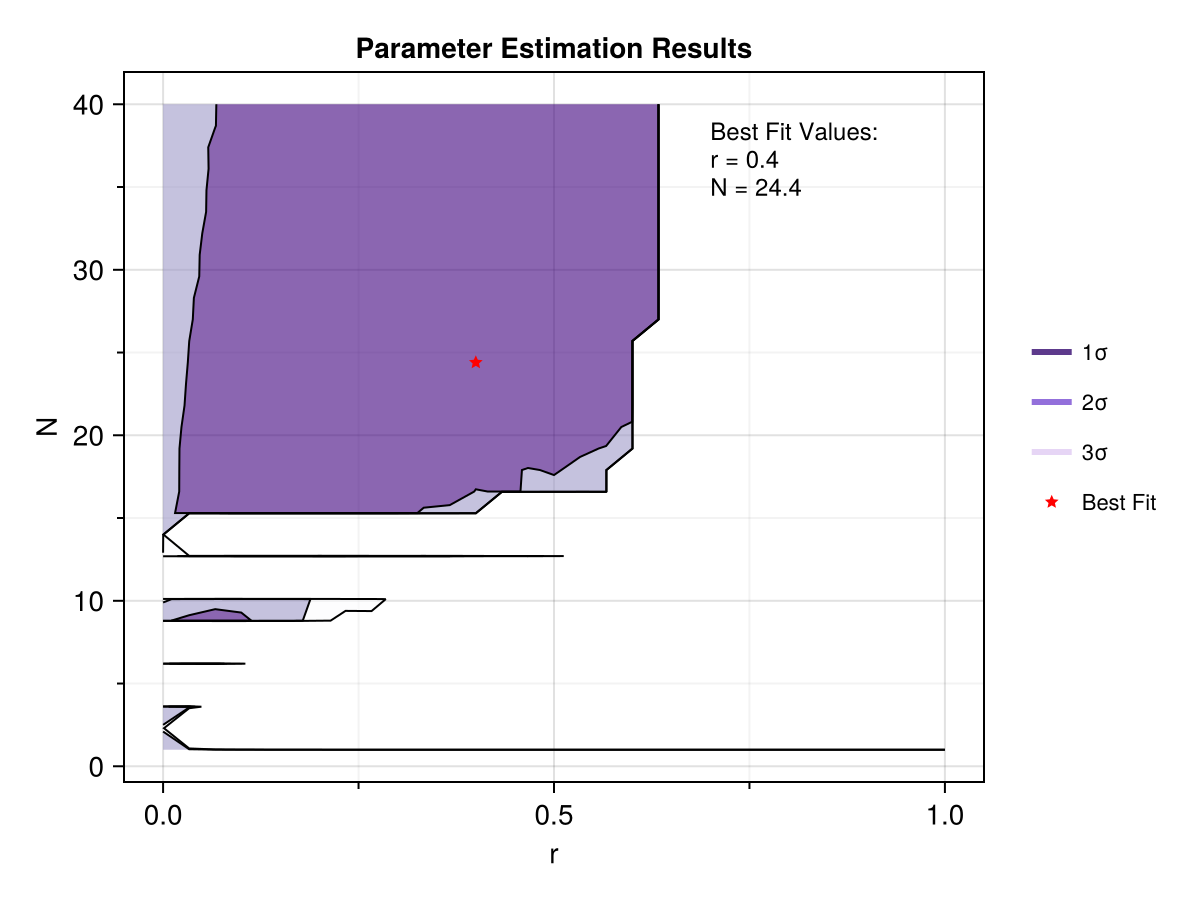

In [ ]:
img = CairoMakie.plot(result)
display("image/png", img)
#save("/home/sofialon/Newtrinos.jl/plots_22/scan_dayabay_Nr_NND_noscale_m0=0.01.png", img)


In [ ]:
bf = Newtrinos.bestfit(result)

# Calculate confidence intervals
sigma_1_threshold = maximum(result.values.log_posterior[:, 15]) - 0.5
sigma_2_threshold = maximum(result.values.log_posterior[:, 15]) - 2.0

# Create the plot
fig = Figure(resolution = (800, 600))
ax = Axis(fig[1, 1],
    xlabel = "r",
    ylabel = "Log Posterior",
    title = "r vs Log posterior - Dayabay NNM",
    titlesize = 16,
    xlabelsize = 14,
    ylabelsize = 14
)

# Plot the main curve
lines!(ax, result.axes.r, result.values.log_posterior[:, 25],
    color = :blue,
    linewidth = 2,
    label = "Log Posterior"
)

# Add confidence level lines
hlines!(ax, [sigma_1_threshold], 
    color = :red, 
    linestyle = :dash, 
    linewidth = 2,
    label = "1σ"
)

hlines!(ax, [sigma_2_threshold], 
    color = :orange, 
    linestyle = :dash, 
    linewidth = 2,
    label = "2σ"
)

# Add legend
axislegend(ax, position = :rb)  # right bottom

display("image/png", fig)
#save("/home/sofialon/Newtrinos.jl/profiled plot/dayabay/dayabay_rLogpost_N=50_m0=0.1_NND.png", fig)


Oscillations


In [135]:

# STANDARD MODEL
E_range = range(0.002, 0.04, length=1000) 
L=1.663
L_vec = [L]

osc_cfg_SM = Newtrinos.osc.OscillationConfig(
    flavour=Newtrinos.osc.ThreeFlavour(),
    propagation=Newtrinos.osc.Basic(),
    states=Newtrinos.osc.All(),
    interaction=Newtrinos.osc.SI()
    )

osc_SM = Newtrinos.osc.configure(osc_cfg_SM)
 

atm_flux = Newtrinos.atm_flux.configure()
earth_layers = Newtrinos.earth_layers.configure()

physics_SM = (; osc=osc_SM, atm_flux, earth_layers);


experiments_SM = (
 
    dayabay = Newtrinos.dayabay.configure(physics_SM),
);

p_SM = Newtrinos.get_params(experiments_SM)

osc_prob_SM = Newtrinos.osc.get_osc_prob(osc_cfg_SM)


probab_SM = osc_prob_SM(collect(E_range), L_vec, p; anti=true)

[ Info: Loading dayabay data


1000×1×3×3 Array{Float64, 4}:
[:, :, 1, 1] =
 0.9717520812960653
 0.9683109007040173
 0.9648651711561107
 0.9614516539986672
 0.9581006425040238
 0.954836715800887
 0.9516794498955481
 0.948644075884838
 0.9457420805008407
 0.9429817476633987
 0.94036864212353
 0.9379060378509995
 0.9355952947774657
 ⋮
 0.9985934515549718
 0.9985961358673033
 0.9985988125173264
 0.9986014815341185
 0.9986041429466216
 0.9986067967836391
 0.9986094430738394
 0.9986120818457556
 0.9986147131277864
 0.998617336948196
 0.9986199533351169
 0.9986225623165482

[:, :, 2, 1] =
 0.005418083717743282
 0.006640561788994135
 0.007947011695303933
 0.009315085502218932
 0.01072495802678424
 0.012159222438124659
 0.013602747738296124
 0.015042513386734001
 0.016467432457965777
 0.017868171654777297
 0.019236974100273762
 0.02056748897953614
 0.02185461068877964
 ⋮
 0.000857674820230858
 0.0008560528141375867
 0.0008544353946927165
 0.0008528225446588595
 0.0008512142468793375
 0.000849610484277723
 0.0008480112398574

In [136]:
# NNATURALNESS WITH DIFFERENT N 


osc_prob = Newtrinos.osc.get_osc_prob(osc_cfg)

p= Newtrinos.get_params(experiments)
p_5 = merge(p, (N = ftype(40),))
p_10 = merge(p, (N = ftype(10),))
p_20 = merge(p, (N = ftype(20),))
p_50 = merge(p, (N = ftype(50),))

probab_5 = osc_prob(collect(E_range), L_vec, p_5; anti=true)
probab_10 = osc_prob(collect(E_range), L_vec, p_10; anti=true)
probab_20 = osc_prob(collect(E_range), L_vec, p_20; anti=true)
probab_50 = osc_prob(collect(E_range), L_vec, p_50; anti=true)

p_0 = merge(p, (r = ftype(0),))
p_025 = merge(p,  (r = ftype(0.25),))
p_05 = merge(p,  (r = ftype(0.5),))
p_1 = merge(p,  (r = ftype(1),))


probab_0 = osc_prob(collect(E_range), L_vec, p_0; anti=true)
probab_025 = osc_prob(collect(E_range), L_vec, p_025; anti=true)
probab_05 = osc_prob(collect(E_range), L_vec, p_05; anti=true)
probab_1 = osc_prob(collect(E_range), L_vec, p_1; anti=true)


Gamma values: 0.025, 0.029706249999999997, 0.17970624999999998
Gamma values: 0.000625, 0.0008824612890624997, 0.03229433628906249
m1 = 0.02
m2 = 0.02180137610335641
m3 = 0.05362182391526793
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00022182490234374993
0.0
7.53e-5
0.0024752999999999997


LoadError: MethodError: no method matching isless(::ComplexF64, ::ComplexF64)
The function `isless` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  isless([91m::Missing[39m, ::Any)
[0m[90m   @[39m [90mBase[39m [90m[4mmissing.jl:87[24m[39m
[0m  isless(::Any, [91m::Missing[39m)
[0m[90m   @[39m [90mBase[39m [90m[4mmissing.jl:88[24m[39m
[0m  isless([91m::Unitful.AbstractQuantity[39m, ::Number)
[0m[90m   @[39m [33mUnitful[39m [90m~/.julia/packages/Unitful/GMTL8/src/[39m[90m[4mquantities.jl:241[24m[39m
[0m  ...


In [31]:
using CairoMakie

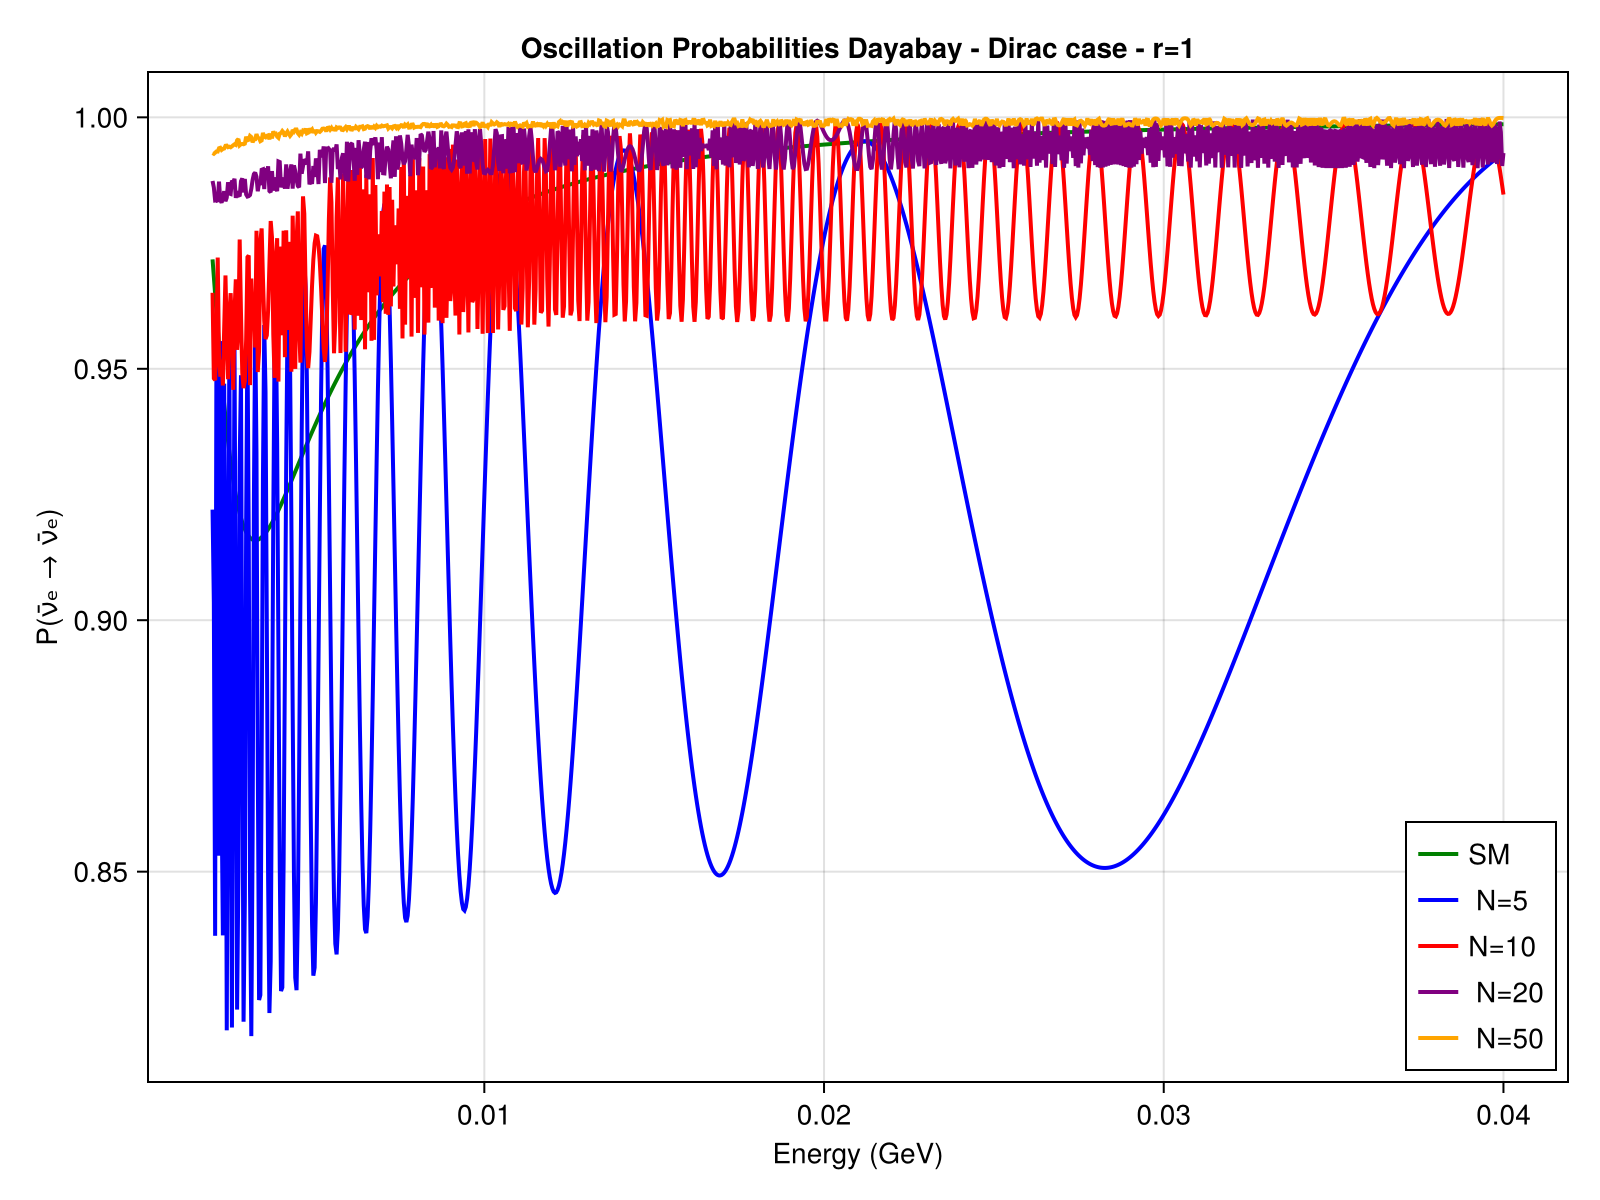

In [32]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "P(ν̄ₑ → ν̄ₑ)", 
    title = "Oscillation Probabilities Dayabay - Dirac case - r=1"
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1,1], label="SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_5[:, 1, 1,1], label=" N=5", linewidth=2, color=:blue)
lines!(ax, E_range, probab_10[:, 1, 1,1], label="N=10", linewidth=2, color=:red)
lines!(ax, E_range, probab_20[:, 1,1,1], label=" N=20", linewidth=2, color=:purple)
lines!(ax, E_range, probab_50[:, 1,1,1], label=" N=50", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
save("/home/sofialon/Newtrinos.jl/plots_22/osc_dayabay_N_NND_m0=0.3_r=0.25.png", fig)

fig

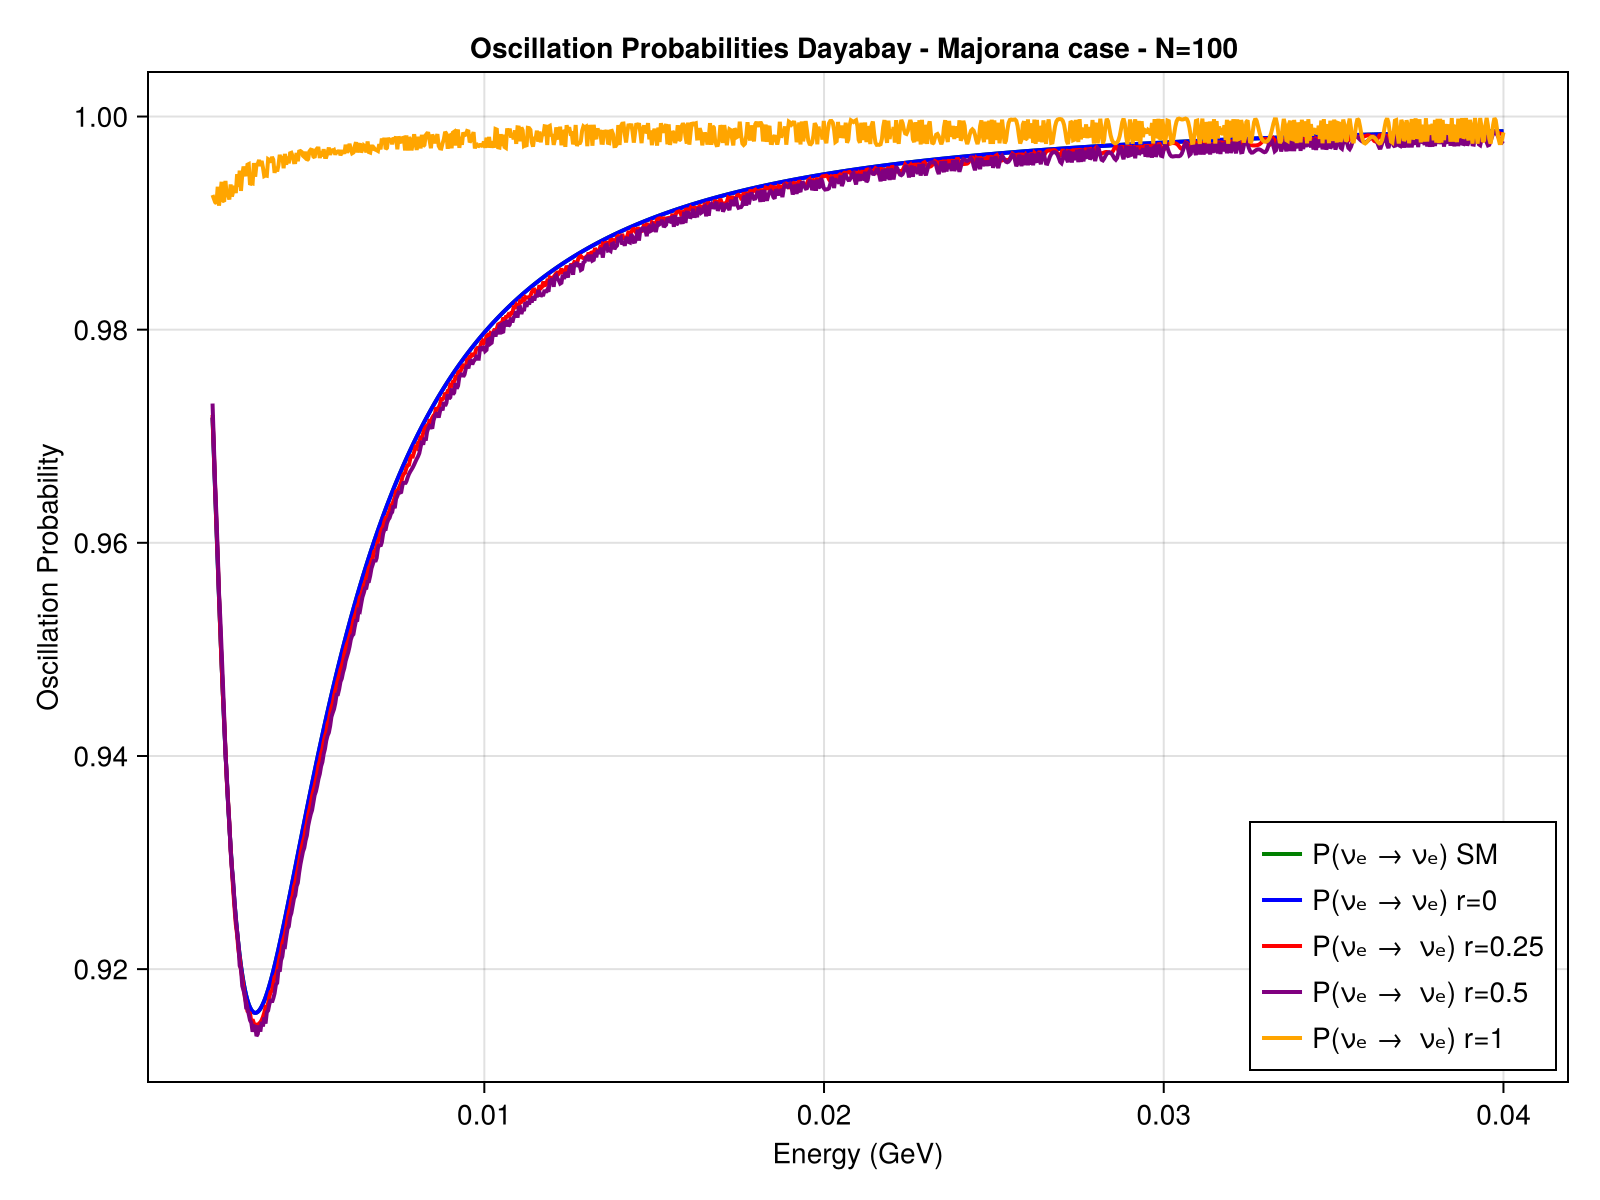

In [33]:

fig = Figure(size=(800, 600))
ax = Axis(fig[1,1], 
    xlabel = "Energy (GeV)",
    ylabel = "Oscillation Probability", 
    title = "Oscillation Probabilities Dayabay - Majorana case - N=100 "
)

# Plot the lines
lines!(ax, E_range, probab_SM[:, 1, 1, 1], label="P(νₑ → νₑ) SM", linewidth=2, color=:green)
lines!(ax, E_range, probab_0[:, 1, 1, 1], label="P(νₑ → νₑ) r=0", linewidth=2, color=:blue)
lines!(ax, E_range, probab_025[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.25", linewidth=2, color=:red)
lines!(ax, E_range, probab_05[:, 1, 1, 1], label="P(νₑ →  νₑ) r=0.5", linewidth=2, color=:purple)
lines!(ax, E_range, probab_1[:, 1, 1, 1], label="P(νₑ →  νₑ) r=1", linewidth=2, color=:orange)

# Add legend and set limits
axislegend(ax, position=:rb)
#save("/home/sofialon/Newtrinos.jl/new_plots/osc_dayabay_r_NND_m0=0.01.png", fig)

fig

In [197]:

f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
    

params_temp = merge(p, (N=100, r =1, m₀=0.3))
H, FinalU, h_temp, norm_sector, norm_gamma, gamma, gamma_sq = f1(params_temp)

params_temp_1= merge(p, (N=100, r =1, m₀=0.01))
H_1, FinalU_1, h_temp_1, norm_sector, norm_gamma, gamma, gamma_sq  = f1(params_temp_1)


fig = Figure(size=(1200,500))
ax1 = Axis(fig[1, 1])
hm = heatmap!(ax1, abs.(H), colormap=:viridis)
Colorbar(fig[1, 2], hm, label="Magnitude")
ax2 = Axis(fig[1,3])
hm = heatmap!(ax2, abs.(H_1), colormap=:viridis)
Colorbar(fig[1, 4], hm, label="Magnitude")

ax1.title = " h matrix m0=0.3 - N=100"
ax2.title = " h matrix m0=0.01 - N=100"

fig
    

save("Mh_100.png", fig)

Gamma values: 0.0001, 0.00010008366666666668, 0.00010275033333333332
Gamma values: 1.0e-8, 1.0016740333444445e-8, 1.055763100011111e-8
m1 = 0.3
m2 = 0.30012547376055904
m3 = 0.304097517253923
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 2.044731633333333e-6
0.0
7.53e-5
0.0024752999999999997
Gamma values: 0.0001, 0.0001753, 0.0025752999999999987
Gamma values: 1.0e-8, 3.073009e-8, 6.6321700899999936e-6
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 5.124846999999997e-5
0.0
7.53e-5
0.0024752999999999997


Eigenvalues plotting

In [140]:


# Plot 1: All eigenvalues vs m1 (scatter plot showing full structure)
function plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="Eigenvalue",
        title="Full Eigenvalue Spectrum vs m₁ - N=50",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Plot eigenvalues at each m1 with color coding
    for (i, m1) in enumerate(m1_values)
        eigs = all_eigenvalues[i]  # This is a 1D vector
        if !isempty(eigs)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot each eigenvalue for this m1
            scatter!(ax, fill(m1, length(eigs)), eigs, 
                markersize=8, color=color, alpha=0.7, 
                label="m₁ = $(round(m1, sigdigits=2))")
        end
    end
    
    axislegend(ax, position=:lt, nbanks=2)
    fig
end


# Plot 2: Eigenvalue ratios vs eigenvalue index (colored by m1)
function plot_eigenvalue_ratios(m1_values, all_ratios)
    fig = Figure(size=(1200, 700))
    ax = Axis(fig[1, 1],
        xlabel="Eigenvalue Index Ratio (i+1 / i)",
        ylabel="Ratio Value",
        title="Consecutive Eigenvalue Ratios - N=50",
        yscale=log10)
    
    colors = [:blue, :red, :green, :orange, :purple, :brown, :pink, :cyan, :magenta, :yellow]
    
    # Each m1 value gets its own color
    for (i, m1) in enumerate(m1_values)
        ratios = all_ratios[i]
        if !isempty(ratios)
            color = colors[mod(i-1, length(colors)) + 1]
            # Plot as line
            lines!(ax, 1:length(ratios), ratios, 
                   label="m₁ = $(round(m1, sigdigits=2))", 
                   linewidth=2.5, color=color)
            # Add markers separately
            scatter!(ax, 1:length(ratios), ratios,
                    markersize=7, color=color)
        end
    end
    
    # Add reference line at y=1 (no hierarchy)
    hlines!(ax, [1.0], color=:black, linestyle=:dash, linewidth=2, label="No structure", alpha=0.5)
    
    axislegend(ax, position=:rt, nbanks=2)
    fig
end


# Plot 3: Perturbation parameter vs m1
function plot_perturbation_parameter(m1_values, all_norm_ratios)
    fig = Figure(size=(1000, 700))
    ax = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="||M_gamma_factor|| / ||M_sector_part||",
        title="Perturbation Validity - N=50",
        yscale=log10
    )
    
    # Filter out NaN values
    valid_idx = .!isnan.(all_norm_ratios)
    valid_m1 = m1_values[valid_idx]
    valid_ratios = all_norm_ratios[valid_idx]
    
    if !isempty(valid_ratios)
        lines!(ax, valid_m1, valid_ratios, linewidth=3, color=:blue, label="Norm ratio")
        scatter!(ax, valid_m1, valid_ratios, markersize=10, color=:blue)
        
        # Add critical threshold lines
        hlines!(ax, [0.01], color=:green, linestyle=:dash, linewidth=2.5, 
                label="Safe perturbation (< 0.1)", alpha=0.7)
        hlines!(ax, [0.03], color=:orange, linestyle=:dash, linewidth=2.5, 
                label="Marginal (0.1-0.3)", alpha=0.7)
        hlines!(ax, [1.0], color=:red, linestyle=:dash, linewidth=2.5, 
                label="Breakdown (> 1)", alpha=0.7)
    end
    
    axislegend(ax, position=:rt)
    fig
end


# Main analysis function
function analyze_m1_limit(base_params, m1_values)
    """
    Analyze eigenvalue structure vs m1 to find the perturbation limit
    
    Args:
        base_params: NamedTuple with base parameters
        m1_values: Vector of m1 values to scan
        get_Nnaturalness_func: Your function that computes eigenvalues
        N_int: Number of sectors
        r: Sector parameter
    """
    
    all_eigenvalues = []
    all_ratios = []
    all_norm_ratios = []
    
    for m1_test in m1_values
        println("Computing for m1 = $m1_test")
        
        # Update parameters with new m1
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Call your function - it should return eigenvalues
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, norm_sector, norm_gamma = f1(params_test)
            
            # Extract ALL eigenvalues from the full matrix
            # Assuming EIG is a Diagonal matrix or eigenvalues vector
            if isa(EIG, Diagonal)
                eigs_sorted = sort(real.(diag(EIG)))
            else
                eigs_sorted = sort(real.(EIG))
            end
            
            push!(all_eigenvalues, eigs_sorted)
            
            # Compute ratios of consecutive eigenvalues
            if length(eigs_sorted) > 1
                ratios = eigs_sorted[2:end] ./ eigs_sorted[1:end-1]
                push!(all_ratios, ratios)
            else
                push!(all_ratios, [])
            end
            
            # Compute norm ratio (perturbation parameter)
            norm_ratio = norm_gamma / norm_sector
            push!(all_norm_ratios, norm_ratio)
            
            println("  -> $(length(eigs_sorted)) eigenvalues, norm ratio = $(round(norm_ratio, sigdigits=3))")
            
        catch e
            println("  Error: $e")
            push!(all_eigenvalues, [])
            push!(all_ratios, [])
            push!(all_norm_ratios, NaN)
        end
    end
    
    return all_eigenvalues, all_ratios, all_norm_ratios
end



function main(N_int)
    """
    Main function to run the analysis
    
    Usage: main(get_Nnaturalness)
    Pass your get_Nnaturalness function as argument
    """
    N=N_int
    
    # MODIFY THESE WITH YOUR ACTUAL VALUES
    base_params =merge(p, (N=50, r=1))
    
    # Logarithmic scan of m1 values
    m1_values = LinRange(0.01, 0.05,10)
    
   
    println("EIGENVALUE STRUCTURE ANALYSIS")
    
    println("Scanning m1 values: $(round.(m1_values, sigdigits=2))\n")
    
    all_eigenvalues, all_ratios, all_norm_ratios = analyze_m1_limit(
        base_params, m1_values
    )
    
    println("GENERATING PLOTS")
    
    
    # Generate Plot 1: Eigenvalues vs m1
    println("Generating Plot 1: Eigenvalues vs m1...")
    fig1 = plot_eigenvalues_vs_m1(m1_values, all_eigenvalues)
    save("eigenvalues_vs_m1_$N.png", fig1)
    println("✓ Saved: eigenvalues_vs_m1.png\n")
    
    # Generate Plot 2: Eigenvalue ratios
    println("Generating Plot 2: Eigenvalue ratios...")
    fig2 = plot_eigenvalue_ratios(m1_values, all_ratios)
    save("eigenvalue_ratios_vs_m1_$N.png", fig2)
    println("✓ Saved: eigenvalue_ratios_vs_m1.png\n")
    
    # Generate Plot 3: Perturbation parameter
    if !isempty(all_norm_ratios) && !all(isnan.(all_norm_ratios))
        println("Generating Plot 3: Perturbation parameter...")
        fig3 = plot_perturbation_parameter(m1_values, all_norm_ratios)
        save("perturbation_parameter_vs_m1_$N.png", fig3)
        println("✓ Saved: perturbation_parameter_vs_m1.png\n")
    else
        println("⚠ Skipping perturbation plot - no valid norm ratios\n")
    end

    return fig1, fig2, all_eigenvalues, all_ratios, all_norm_ratios
end


# To use this script:
# 1. Make sure your get_Nnaturalness function returns:
#    EIG, FinalUmatrix, h, norm_sector, norm_gamma
# 
fig1, fig2, eigs, ratios, norms = main(50)
#
# Color scheme:
# - Blue: smallest m1 values
# - Red, Green, Orange, etc: progressively larger m1 values
# - Each color appears consistently across all three plots

EIGENVALUE STRUCTURE ANALYSIS
Scanning m1 values: [0.01, 0.014, 0.019, 0.023, 0.028, 0.032, 0.037, 0.041, 0.046, 0.05]

Computing for m1 = 0.01
Gamma values: 0.02, 0.03506, 0.5150599999999997
Gamma values: 0.0004, 0.0012292035999999999, 0.2652868035999998
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00040792751999999964
0.0
7.53e-5
0.0024752999999999997
  -> 150 eigenvalues, norm ratio = 0.000408
Computing for m1 = 0.014444444444444444
Gamma values: 0.02, 0.027218106508875742, 0.25727727810650886
Gamma values: 0.0004, 0.000740825321928504, 0.06619159782989388
m1 = 0.014444444444444444
m2 = 0.016850577892423807
m3 = 0.05180677538033651
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.00020376360426035495
0.0
7.53e-5
0.0024752999999999997
  -> 150 eigenvalues, norm ratio = 0.000204
Computing for m1 = 0.01888888888888889
Gamma values: 0.02, 0.02422096885813149, 0.15875384083044977
Gamma values: 0.0004, 0.0005866553324265754,

(Scene (1200px, 700px):
  0 Plots
  2 Child Scenes:
    ├ Scene (1200px, 700px)
    └ Scene (1200px, 700px), Scene (1200px, 700px):
  0 Plots
  2 Child Scenes:
    ├ Scene (1200px, 700px)
    └ Scene (1200px, 700px), Any[[0.02038992588406931, 0.035743536065006284, 0.061103046091602935, 0.10176064757519784, 0.10711362913224051, 0.1423797389900227, 0.17838639896281341, 0.18296963262567142, 0.2235363731997621, 0.24959166137890046  …  44.363485632145284, 45.41418842618963, 46.466869006957715, 47.522300506075176, 48.58187408445507, 49.648582404271856, 50.73158137858396, 125001.33320177742, 125002.33710506205, 125034.33507835171], [0.020389925883950732, 0.02774875722902053, 0.061103046091516545, 0.08315545685795514, 0.10176064757503739, 0.13848660116435418, 0.1423797389902347, 0.1829696326258417, 0.1937653371867572, 0.22353637320015238  …  22.159981297079586, 22.68481683970137, 23.210640257582252, 23.73783772342068, 24.267104111281668, 24.799934235530813, 25.340901425852955, 125001.333201777

Gamma plotting

In [174]:


function plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    """
    Plot gamma and gamma^2 values vs m1
    
    Args:
        m1_values: Vector of m1 values
        all_gamma: Vector of gamma vectors (3 values each)
        all_gamma_squared: Vector of gamma^2 vectors (3 values each)
    """
    
    fig = Figure(size=(1400, 600))
    
    # Plot 1: gamma values
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ value",
        title="γ vs m₁ - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁ = m₁²/m₁²", "γ₂ = m₂²/m₁²", "γ₃ = m₃²/m₁²"]
    
    # Plot each gamma component
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        lines!(ax1, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, gamma_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: gamma^2 values
    ax2 = Axis(fig[1, 2],
        xlabel="m₁ (eV)",
        ylabel="γ² value",
        title="γ² vs m₁  - N=10",
        yscale=log10)
    
    labels_sq = ["γ₁² = m₁⁴/m₁⁴", "γ₂² = m₂⁴/m₁⁴", "γ₃² = m₃⁴/m₁⁴"]
    
    # Plot each gamma^2 component
    for component in 1:3
        gamma_sq_component = [all_gamma_squared[i][component] for i in 1:length(m1_values)]
        lines!(ax2, m1_values, gamma_sq_component, 
               linewidth=2.5, color=colors[component], label=labels_sq[component])
        scatter!(ax2, m1_values, gamma_sq_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax2, position=:rt)
    
    fig
end


function plot_gamma_ratio(m1_values, all_gamma, all_gamma_squared)
    """
    Plot ratio γ²/γ for each component (should equal γ)
    """
    
    fig = Figure(size=(1200, 600))
    
    # Plot 1: Ratio γ²/γ
    ax1 = Axis(fig[1, 1],
        xlabel="m₁ (eV)",
        ylabel="γ²/γ",
        title="Ratio γ²/γ vs m₁  - N=10",
        yscale=log10)
    
    colors = [:blue, :red, :green]
    labels = ["γ₁²/γ₁", "γ₂²/γ₂", "γ₃²/γ₃"]
    
    # Compute ratios γ²/γ for each component
    for component in 1:3
        ratio_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        lines!(ax1, m1_values, ratio_component, 
               linewidth=2.5, color=colors[component], label=labels[component])
        scatter!(ax1, m1_values, ratio_component, 
                markersize=8, color=colors[component])
    end
    
    axislegend(ax1, position=:rt)
    
    # Plot 2: Direct comparison γ vs γ²/γ (verification they're the same)
   #= ax2 = Axis(fig[1, 2],
        xlabel="m₁ (GeV)",
        ylabel="Value",
        title="Verification: γ (line) vs γ²/γ (scatter)",
        xscale=log10,
        yscale=log10)
    
    for component in 1:3
        gamma_component = [all_gamma[i][component] for i in 1:length(m1_values)]
        ratio_component = [all_gamma_squared[i][component] / all_gamma[i][component] 
                          for i in 1:length(m1_values)]
        
        # Plot γ as line
        lines!(ax2, m1_values, gamma_component, 
               linewidth=2.5, color=colors[component], linestyle=:solid, alpha=0.7)
        # Plot γ²/γ as scatter to verify they match
        scatter!(ax2, m1_values, ratio_component, 
                markersize=6, color=colors[component], marker=:circle)
    end
    =#
    fig
end


# Example usage:
function main_gamma(m1_values, base_params)
    """
    Main function to analyze gamma values
    
    Usage: main_gamma(m1_values, get_Nnaturalness, base_params)
    """
    
    all_gamma = []
    all_gamma_squared = []
    
    println("Computing gamma values for different m1...")
    
    for m1_test in m1_values
        params_test = merge(base_params, (m₀=m1_test,))
        
        try
            # Your function should return gamma values
            # Modify this based on what your get_Nnaturalness returns
            f1 = Newtrinos.osc.get_matrices(osc_cfg.flavour)
            EIG, FinalU, h, norm_sector, norm_gamma, gamma, gamma_sq = f1(params_test)
          
            
            push!(all_gamma, gamma)
            push!(all_gamma_squared, gamma_sq)
            
            println("m1 = $m1_test: γ = $gamma")
            
        catch e
            println("Error for m1 = $m1_test: $e")
        end
    end
    
    # Generate plots
    fig1 = plot_gamma_values(m1_values, all_gamma, all_gamma_squared)
    save("gamma_values_vs_m1_N10.png", fig1)
    println("\n✓ Saved: gamma_values_vs_m1.png")
    
    fig2 = plot_gamma_ratio(m1_values, all_gamma, all_gamma_squared)
    save("gamma_ratios_vs_m1_N10.png", fig2)
    println("✓ Saved: gamma_ratios_vs_m1.png")
    
    return fig1, fig2, all_gamma, all_gamma_squared
end
   
# MODIFY THESE WITH YOUR ACTUAL VALUES
base_params =merge(p, (N=50, r=1))

# Logarithmic scan of m1 values
m1_values = LinRange(0.01, 0.05,10)

   
fig1, fig2, all_gamma, all_gamma_squared=main_gamma(m1_values, p)

Computing gamma values for different m1...
Gamma values: 0.01, 0.017529999999999997, 0.2575299999999999
Gamma values: 0.00010000000000000002, 0.00030730089999999997, 0.06632170089999995
m1 = 0.01
m2 = 0.01324009063413087
m3 = 0.050747413727203865
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.04893069999999998
0.0
7.53e-5
0.0024752999999999997
m1 = 0.01: γ = [0.1, 0.17529999999999998, 2.575299999999999]
Gamma values: 0.01, 0.01360905325443787, 0.1286386390532544
Gamma values: 0.00010000000000000002, 0.00018520633048212595, 0.01654789945747347
m1 = 0.014444444444444444
m2 = 0.016850577892423807
m3 = 0.05180677538033651
Ratio ||M_gamma_factor|| / ||M_sector_part|| = 0.024441341420118338
0.0
7.53e-5
0.0024752999999999997
m1 = 0.014444444444444444: γ = [0.1, 0.1360905325443787, 1.286386390532544]
Gamma values: 0.01, 0.012110484429065744, 0.07937692041522489
Gamma values: 0.00010000000000000002, 0.00014666383310664384, 0.006300695494604944
m1 = 0.01888888888888889
m2 = 0.02078677761118327

(Scene (1400px, 600px):
  0 Plots
  4 Child Scenes:
    ├ Scene (1400px, 600px)
    ├ Scene (1400px, 600px)
    ├ Scene (1400px, 600px)
    └ Scene (1400px, 600px), Scene (1200px, 600px):
  0 Plots
  2 Child Scenes:
    ├ Scene (1200px, 600px)
    └ Scene (1200px, 600px), Any[[0.1, 0.17529999999999998, 2.575299999999999], [0.1, 0.1360905325443787, 1.286386390532544], [0.1, 0.12110484429065745, 0.7937692041522488], [0.1, 0.11383061224489795, 0.5546469387755101], [0.1, 0.10975888000000003, 0.4207988799999999], [0.1, 0.10725243757431628, 0.3384058263971463], [0.1, 0.105600826446281, 0.2841132231404958], [0.1, 0.10445529583637689, 0.24645675675675677], [0.1, 0.1036283759666865, 0.2192738251041047], [0.1, 0.10301200000000002, 0.19901199999999997]], Any[[0.010000000000000002, 0.030730089999999995, 6.632170089999995], [0.010000000000000002, 0.018520633048212595, 1.6547899457473472], [0.010000000000000002, 0.014666383310664385, 0.6300695494604944], [0.010000000000000002, 0.012957408284048311, 